# 06 — Dissertation results visualisation

**Purpose:** generate the additional publication-quality figures used in Chapter 4 directly from the **frozen final analysis outputs**.

This notebook does **not** refit, retune, reselect or modify any predictive model. It is a reporting/visualisation stage only.

It formally reproduces the five figures added to the final Results chapter:

1. Observed IMD 2025 deprivation classes across Leeds LSOAs.
2. Mean proportions of the five most prevalent semantic classes by deprivation class.
3. Final five frozen spatial cross-validation folds.
4. Fold-wise macro-F1 gain from retaining the full 19-class semantic representation.
5. Selected Random Forest macro-F1 across the five outer spatial folds.

It also exports the deprivation-stratified semantic summary table used in Chapter 4 and writes an output audit/manifest.

### Analytical guardrails

- Use only the frozen final production outputs.
- Do not alter the LSOA-to-fold mapping.
- Do not refit or retune models.
- Do not use this notebook for model selection.
- The deprivation-stratified table reports **all 19 semantic classes**; the plotted subset is selected only by overall prevalence, not by SHAP importance or model performance.
- Descriptive feature-by-deprivation summaries are **descriptive**, not causal or inferential effects.
- The 19 semantic proportions are compositional and should not be interpreted as independent unconstrained variables.
- Macro-F1 remains the pre-specified primary model-selection metric from Notebook 04.

## 1. Google Drive setup

The project paths below mirror the final production notebooks. If the notebook is run outside Colab, replace `PROJECT_DIR` with the local project path.

In [1]:
from pathlib import Path

IN_COLAB = False
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    pass

if IN_COLAB:
    PROJECT_DIR = Path("/content/drive/MyDrive/leeds_gsv_project")
else:
    # Override for local runs.
    PROJECT_DIR = Path.cwd() / "leeds_gsv_project"

OUTPUT_DIR = PROJECT_DIR / "outputs_10points_metadata_once"

SEGMENTATION_DIR = OUTPUT_DIR
QA_DIR = OUTPUT_DIR / "dataset_quality_assurance"
MODELLING_DIR = OUTPUT_DIR / "nested_spatial_modelling_grouped_vs_full19"
SPATIAL_DIAGNOSTICS_DIR = OUTPUT_DIR / "spatial_residual_diagnostics_random_forest_full19_raw"

VIS_DIR = OUTPUT_DIR / "chapter4_results_visualisation_final"
FIGURE_DIR = VIS_DIR / "figures"
TABLE_DIR = VIS_DIR / "tables"

for folder in (VIS_DIR, FIGURE_DIR, TABLE_DIR):
    folder.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Visualisation output directory:", VIS_DIR)

## 2. Frozen inputs and configuration

The final SegFormer production notebook writes the LSOA feature table and frozen fold map directly under `outputs_10points_metadata_once`; the modelling and spatial-diagnostic outputs remain in their dedicated subfolders.


In [2]:
# Frozen inputs
LSOA_FEATURES_FILE = SEGMENTATION_DIR / "segmentation_lsoa_features_19class_mean_sd.csv"
FOLD_MAP_FILE = SEGMENTATION_DIR / "lsoa_spatial_plus_fold_mapping.csv"

MODEL_COMPARISON_FILE = MODELLING_DIR / "nested_spatial_model_comparison.csv"
OUTER_METRICS_FILE = MODELLING_DIR / "nested_spatial_outer_fold_metrics.csv"
PAIRED_REPRESENTATION_FILE = MODELLING_DIR / "nested_spatial_representation_paired_comparison.csv"
SELECTED_MODEL_OOF_FILE = MODELLING_DIR / "selected_model_oof_spatial_diagnostics.csv"

SPATIAL_GPKG_FILE = SPATIAL_DIAGNOSTICS_DIR / "oof_spatial_diagnostics.gpkg"

EXPECTED_N_LSOAS = 488
EXPECTED_FOLDS = {1, 2, 3, 4, 5}
EXPECTED_SELECTED_MODEL = "random_forest_full19_raw"

# Figure and table outputs
CLASS_FEATURE_SUMMARY_CSV = TABLE_DIR / "chapter4_all19_semantic_proportions_by_deprivation_class.csv"
FOLD_BALANCE_CSV = TABLE_DIR / "chapter4_final_fold_balance.csv"

OBSERVED_IMD_MAP_PNG = FIGURE_DIR / "chapter4_observed_imd2025_deprivation_classes.png"
CLASS_FEATURE_PROFILE_PNG = FIGURE_DIR / "chapter4_top5_prevalent_semantic_proportions_by_deprivation_class.png"
SPATIAL_FOLDS_MAP_PNG = FIGURE_DIR / "chapter4_final_five_spatial_folds.png"
REPRESENTATION_GAIN_PNG = FIGURE_DIR / "chapter4_full19_minus_grouped_fold_macro_f1.png"
SELECTED_FOLD_PERFORMANCE_PNG = FIGURE_DIR / "chapter4_selected_rf_outer_fold_macro_f1.png"

OUTPUT_AUDIT_CSV = VIS_DIR / "chapter4_visualisation_output_audit.csv"
RUN_MANIFEST_JSON = VIS_DIR / "chapter4_visualisation_run_manifest.json"

required_files = [
    LSOA_FEATURES_FILE,
    FOLD_MAP_FILE,
    MODEL_COMPARISON_FILE,
    OUTER_METRICS_FILE,
    PAIRED_REPRESENTATION_FILE,
    SELECTED_MODEL_OOF_FILE,
    SPATIAL_GPKG_FILE,
]

missing = [str(p) for p in required_files if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Required frozen inputs are missing:\n- " + "\n- ".join(missing)
    )

print("All required frozen inputs found.")

## 3. Imports and reproducibility helpers

In [3]:
import hashlib
import json
import platform
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import sklearn

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()

def save_figure(path):
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Saved:", path)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("geopandas:", gpd.__version__)
print("scikit-learn:", sklearn.__version__)

## 4. Load and validate the frozen outputs

This cell checks the same core identities used by the final modelling and spatial-diagnostic notebooks.

In [4]:
features = pd.read_csv(LSOA_FEATURES_FILE)
fold_map = pd.read_csv(FOLD_MAP_FILE)
model_comparison = pd.read_csv(MODEL_COMPARISON_FILE)
outer_metrics = pd.read_csv(OUTER_METRICS_FILE)
paired_representation = pd.read_csv(PAIRED_REPRESENTATION_FILE)
selected_oof = pd.read_csv(SELECTED_MODEL_OOF_FILE)
spatial = gpd.read_file(SPATIAL_GPKG_FILE)

print("Feature table:", features.shape)
print("Fold map:", fold_map.shape)
print("Spatial diagnostics:", spatial.shape)

assert len(features) == EXPECTED_N_LSOAS
assert features["LSOA21CD"].nunique() == EXPECTED_N_LSOAS
assert set(fold_map["spatial_fold"].unique()) == EXPECTED_FOLDS
assert fold_map["LSOA21CD"].nunique() == EXPECTED_N_LSOAS
assert selected_oof["LSOA21CD"].nunique() == EXPECTED_N_LSOAS
assert spatial["LSOA21CD"].nunique() == EXPECTED_N_LSOAS

if "model" in selected_oof.columns:
    models = set(selected_oof["model"].dropna().unique())
    assert models == {EXPECTED_SELECTED_MODEL}, models

required_classes = {
    "High Deprivation",
    "Medium Deprivation",
    "Low Deprivation",
}
assert set(features["DeprivationClass"].unique()) == required_classes

# Ensure one frozen fold per LSOA and no disagreement between sources.
fold_check = (
    fold_map[["LSOA21CD", "spatial_fold"]]
    .merge(
        selected_oof[["LSOA21CD", "spatial_fold"]],
        on="LSOA21CD",
        suffixes=("_map", "_oof"),
        validate="one_to_one",
    )
)
assert (fold_check["spatial_fold_map"] == fold_check["spatial_fold_oof"]).all()

print("Frozen-output validation passed.")


## 5. Create the Chapter 4 descriptive tables

The deprivation-stratified semantic table reports **all 19 Cityscapes classes** from the final 488-LSOA feature table. No feature is omitted from this descriptive table.

For the accompanying figure, the five displayed classes are selected using one transparent, model-independent rule: **the five semantic classes with the highest overall mean pixel proportion across all 488 LSOAs**. The selection is therefore independent of SHAP importance, model ranking and class-specific predictive performance.

The class-specific means remain descriptive rather than inferential results. Because the semantic variables form a closed composition, they should not be interpreted as independent effects.


In [5]:
CLASS_ORDER = [
    "High Deprivation",
    "Medium Deprivation",
    "Low Deprivation",
]

# All 19 Cityscapes semantic means used by the full representation.
ALL19_FEATURES = [
    "seg_road_mean",
    "seg_sidewalk_mean",
    "seg_building_mean",
    "seg_wall_mean",
    "seg_fence_mean",
    "seg_pole_mean",
    "seg_traffic_light_mean",
    "seg_traffic_sign_mean",
    "seg_vegetation_mean",
    "seg_terrain_mean",
    "seg_sky_mean",
    "seg_person_mean",
    "seg_rider_mean",
    "seg_car_mean",
    "seg_truck_mean",
    "seg_bus_mean",
    "seg_train_mean",
    "seg_motorcycle_mean",
    "seg_bicycle_mean",
]

PRETTY = {
    c: c.replace("seg_", "").replace("_mean", "").replace("_", " ").title()
    for c in ALL19_FEATURES
}

missing_features = sorted(set(ALL19_FEATURES) - set(features.columns))
if missing_features:
    raise KeyError(f"Missing semantic feature columns: {missing_features}")

# Complete 19-class table by deprivation class.
class_means = (
    features.groupby("DeprivationClass")[ALL19_FEATURES]
    .mean()
    .loc[CLASS_ORDER]
    * 100.0
)

summary_table = class_means.T.reset_index().rename(columns={"index": "feature"})
summary_table["feature"] = summary_table["feature"].map(PRETTY)
summary_table.to_csv(CLASS_FEATURE_SUMMARY_CSV, index=False)

display(summary_table.round(3))
print("Saved complete 19-class table:", CLASS_FEATURE_SUMMARY_CSV)

# Select the plotted subset using overall prevalence only.
overall_prevalence = (
    features[ALL19_FEATURES].mean().sort_values(ascending=False) * 100.0
)
TOP5_PREVALENT_FEATURES = overall_prevalence.head(5).index.tolist()

print("\nFive most prevalent semantic classes across all 488 LSOAs:")
for feature in TOP5_PREVALENT_FEATURES:
    print(f"  {PRETTY[feature]}: {overall_prevalence[feature]:.3f}%")

fold_balance = (
    pd.crosstab(fold_map["spatial_fold"], fold_map["DeprivationClass"])
    .reindex(columns=CLASS_ORDER, fill_value=0)
)
fold_balance["Total LSOAs"] = fold_balance.sum(axis=1)
fold_balance["Images"] = (
    fold_map.groupby("spatial_fold")["n_images_segmented"].sum()
)
fold_balance.to_csv(FOLD_BALANCE_CSV)

display(fold_balance)
print("Saved:", FOLD_BALANCE_CSV)

DeprivationClass        feature  High Deprivation  Medium Deprivation  \
0                          Road            30.359              29.545   
1                      Sidewalk             4.170               4.012   
2                      Building            11.358              11.240   
3                          Wall             1.092               1.397   
4                         Fence             1.936               1.559   
5                          Pole             0.340               0.334   
6                 Traffic Light             0.012               0.011   
7                  Traffic Sign             0.063               0.072   
8                    Vegetation            11.449              13.952   
9                       Terrain             3.406               3.348   
10                          Sky            33.134              32.144   
11                       Person             0.080               0.077   
12                        Rider             0.003  

Saved complete 19-class table: <PROJECT_DIR>/outputs_10points_metadata_once/chapter4_results_visualisation_final/tables/chapter4_all19_semantic_proportions_by_deprivation_class.csv

Five most prevalent semantic classes across all 488 LSOAs:
  Sky: 32.374%
  Road: 29.578%
  Vegetation: 14.134%
  Building: 10.646%
  Sidewalk: 4.102%


DeprivationClass  High Deprivation  Medium Deprivation  Low Deprivation  \
spatial_fold                                                              
1                               34                  30               34   
2                               35                  29               34   
3                               37                  29               33   
4                               35                  28               33   
5                               35                  29               33   

DeprivationClass  Total LSOAs  Images  
spatial_fold                           
1                          98    3860  
2                          98    3888  
3                          99    3948  
4                          96    3812  
5                          97    3864  

Saved: <PROJECT_DIR>/outputs_10points_metadata_once/chapter4_results_visualisation_final/tables/chapter4_final_fold_balance.csv


## 6. Figure 1 — Observed IMD 2025 deprivation classes

This map shows the spatial distribution of the outcome the models are attempting to predict. It is a descriptive map, not a model output.

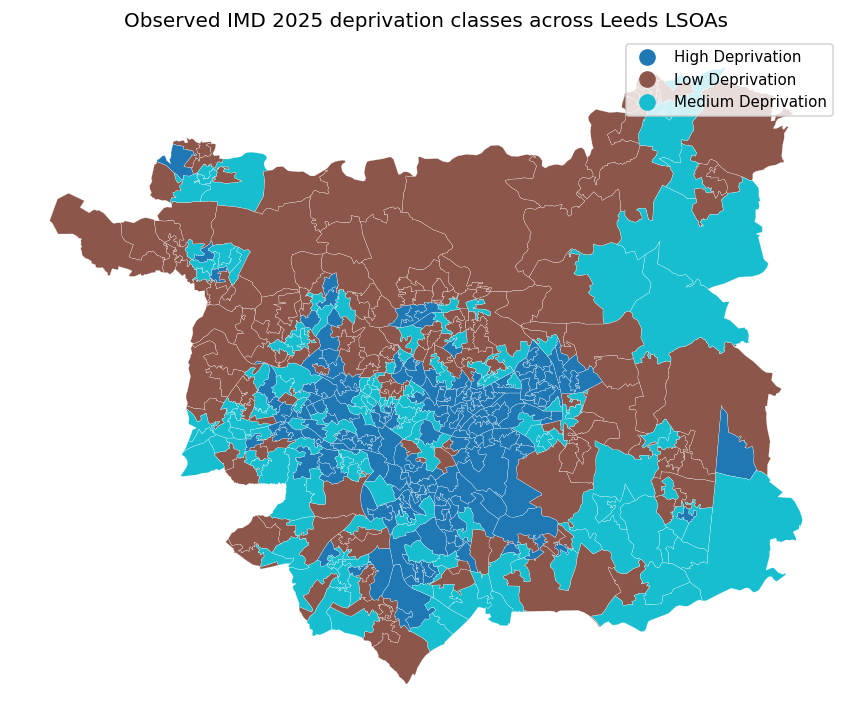

Saved: <PROJECT_DIR>/outputs_10points_metadata_once/chapter4_results_visualisation_final/figures/chapter4_observed_imd2025_deprivation_classes.png


In [6]:
fig, ax = plt.subplots(figsize=(7.2, 7.2))

spatial.plot(
    column="DeprivationClass",
    categorical=True,
    legend=True,
    linewidth=0.15,
    edgecolor="white",
    ax=ax,
)

ax.set_title("Observed IMD 2025 deprivation classes across Leeds LSOAs")
ax.set_axis_off()

save_figure(OBSERVED_IMD_MAP_PNG)


## 7. Figure 2 — Five most prevalent semantic classes by deprivation class

The plotted classes are selected **only from their overall prevalence across the full 488-LSOA dataset**. This avoids selecting features because they later appeared important in SHAP or because their class differences look visually large.

The complete class-specific means for all 19 semantic categories are retained in the exported table.

The figure is descriptive. It does not estimate causal effects, independent coefficients or statistical significance.


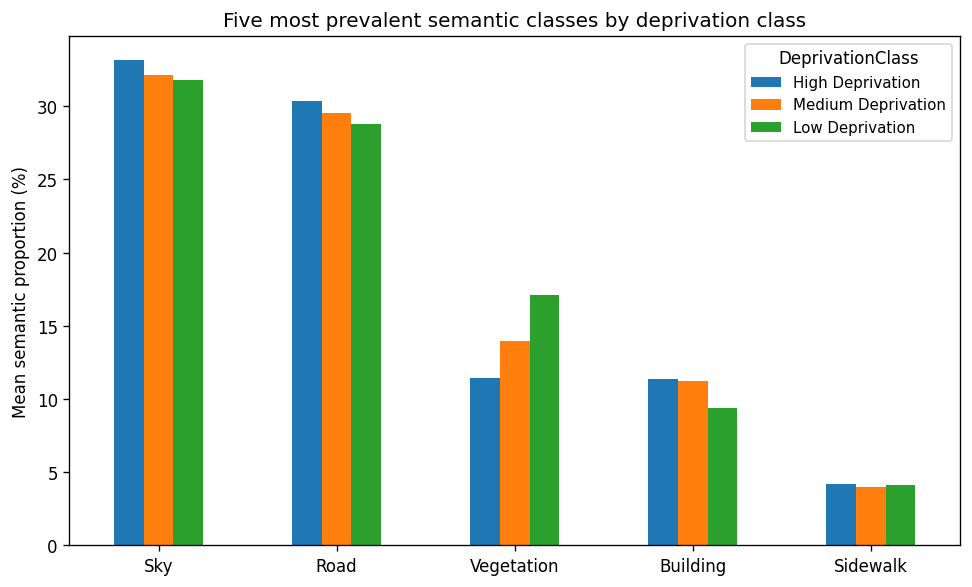

Saved: <PROJECT_DIR>/outputs_10points_metadata_once/chapter4_results_visualisation_final/figures/chapter4_top5_prevalent_semantic_proportions_by_deprivation_class.png


In [7]:
profile = class_means[TOP5_PREVALENT_FEATURES].T.copy()
profile.index = [PRETTY[c] for c in TOP5_PREVALENT_FEATURES]

ax = profile.plot(
    kind="bar",
    figsize=(8.2, 5.0),
)

ax.set_title("Five most prevalent semantic classes by deprivation class")
ax.set_xlabel("")
ax.set_ylabel("Mean semantic proportion (%)")
ax.tick_params(axis="x", rotation=0)

save_figure(CLASS_FEATURE_PROFILE_PNG)

## 8. Figure 3 — Final five frozen spatial cross-validation folds

This map visualises the exact fold allocation used unchanged by all six primary candidate models.

The mapping is read from the frozen production fold file; this notebook does not recreate or optimise the folds.

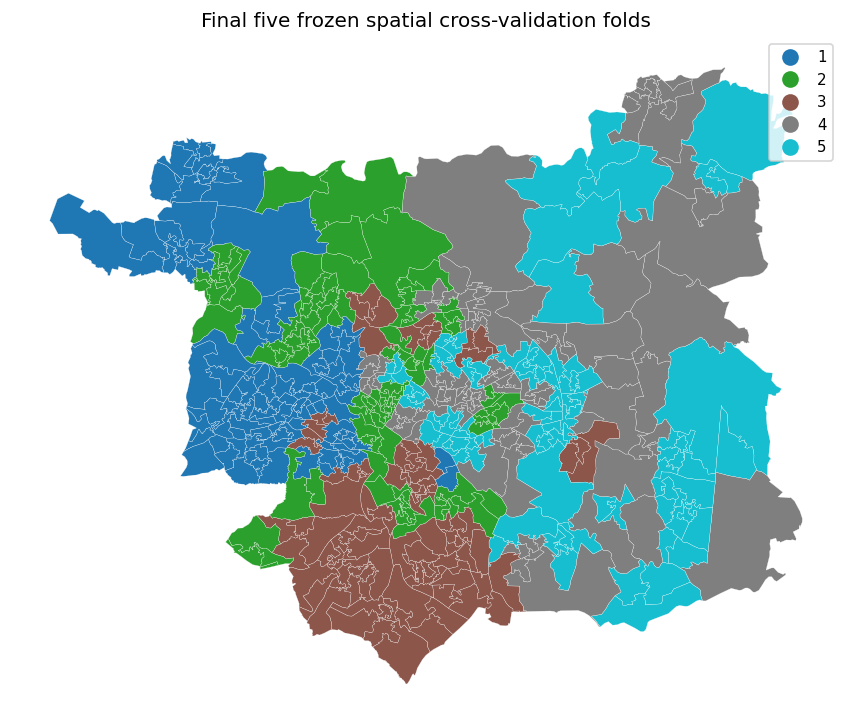

Saved: <PROJECT_DIR>/outputs_10points_metadata_once/chapter4_results_visualisation_final/figures/chapter4_final_five_spatial_folds.png


In [8]:
fold_geometry = (
    spatial.drop(columns=["spatial_fold"], errors="ignore")
    .merge(
        fold_map[["LSOA21CD", "spatial_fold"]],
        on="LSOA21CD",
        how="left",
        validate="one_to_one",
    )
)

assert fold_geometry["spatial_fold"].notna().all()

fig, ax = plt.subplots(figsize=(7.2, 7.2))

fold_geometry.plot(
    column="spatial_fold",
    categorical=True,
    legend=True,
    linewidth=0.15,
    edgecolor="white",
    ax=ax,
)

ax.set_title("Final five frozen spatial cross-validation folds")
ax.set_axis_off()

save_figure(SPATIAL_FOLDS_MAP_PNG)

## 9. Figure 4 — Fold-wise gain from the full 19-class representation

For each algorithm and outer spatial fold:

\[
\Delta F1_{macro} = F1_{macro, full19} - F1_{macro, grouped7}
\]

Values above zero indicate better macro-F1 for the full semantic representation.

This is a paired visualisation because each grouped/full comparison uses the same frozen held-out fold.

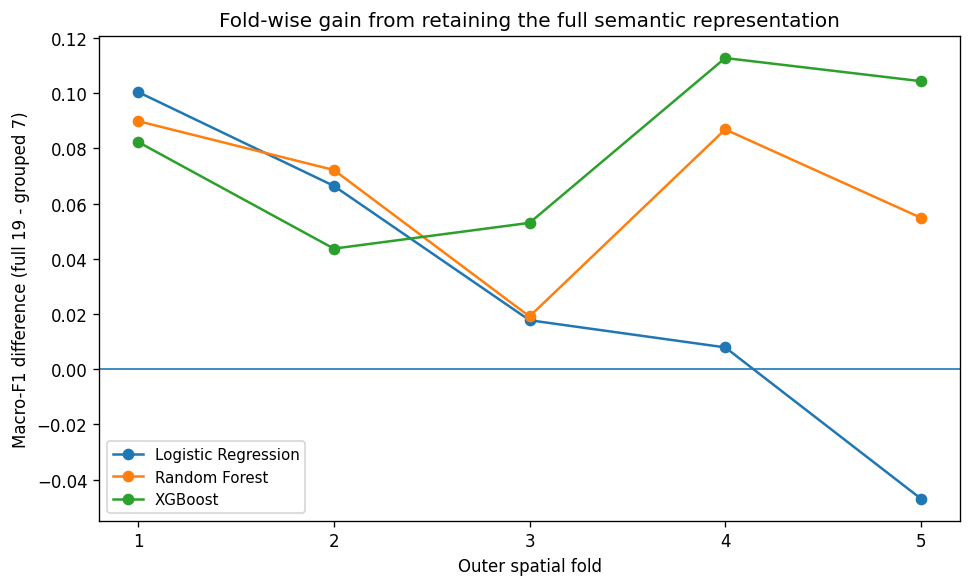

Saved: <PROJECT_DIR>/outputs_10points_metadata_once/chapter4_results_visualisation_final/figures/chapter4_full19_minus_grouped_fold_macro_f1.png


In [9]:
MODEL_PAIRS = [
    (
        "Logistic Regression",
        "logistic_grouped_clr",
        "logistic_full19_ilr",
    ),
    (
        "Random Forest",
        "random_forest_grouped_raw",
        "random_forest_full19_raw",
    ),
    (
        "XGBoost",
        "xgboost_grouped_raw",
        "xgboost_full19_raw",
    ),
]

fig, ax = plt.subplots(figsize=(8.2, 5.0))

for label, grouped_model, full_model in MODEL_PAIRS:
    grouped = (
        outer_metrics.loc[
            outer_metrics["model"] == grouped_model,
            ["outer_fold", "f1_macro"],
        ]
        .sort_values("outer_fold")
        .set_index("outer_fold")["f1_macro"]
    )
    full = (
        outer_metrics.loc[
            outer_metrics["model"] == full_model,
            ["outer_fold", "f1_macro"],
        ]
        .sort_values("outer_fold")
        .set_index("outer_fold")["f1_macro"]
    )

    assert grouped.index.equals(full.index)
    delta = full - grouped

    ax.plot(
        delta.index,
        delta.values,
        marker="o",
        label=label,
    )

ax.axhline(0, linewidth=1)
ax.set_xticks(sorted(EXPECTED_FOLDS))
ax.set_xlabel("Outer spatial fold")
ax.set_ylabel("Macro-F1 difference (full 19 - grouped 7)")
ax.set_title("Fold-wise gain from retaining the full semantic representation")
ax.legend()

save_figure(REPRESENTATION_GAIN_PNG)

## 10. Figure 5 — Selected Random Forest performance across outer folds

The selected model is fixed as `random_forest_full19_raw`, as determined in the final nested spatial modelling notebook.

This figure reports geographic variability in held-out macro-F1; it does not perform further model selection.

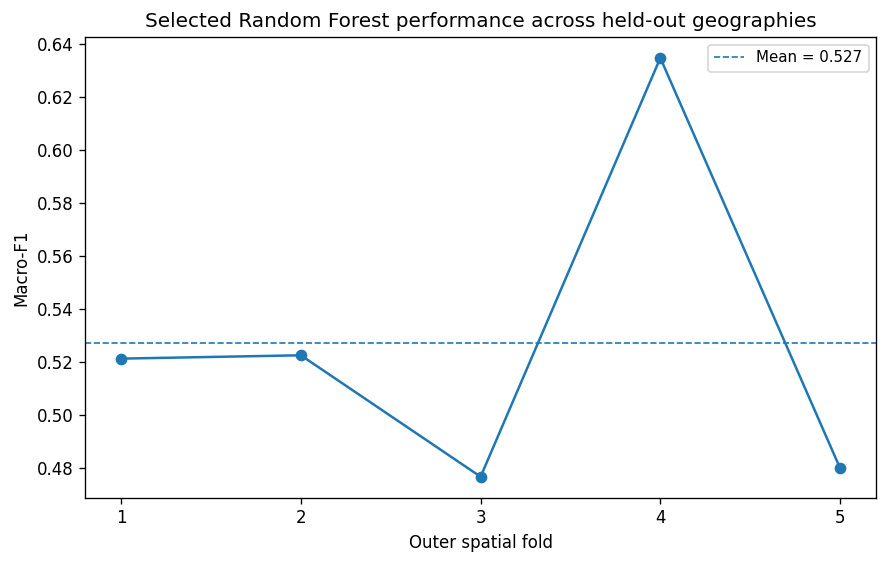

Saved: <PROJECT_DIR>/outputs_10points_metadata_once/chapter4_results_visualisation_final/figures/chapter4_selected_rf_outer_fold_macro_f1.png


    outer_fold  n_test  f1_macro  balanced_accuracy  accuracy  log_loss  \
20           1      98     0.521              0.525     0.520     1.005   
21           2      98     0.522              0.527     0.541     0.937   
22           3      99     0.477              0.492     0.515     0.927   
23           4      96     0.635              0.642     0.656     0.862   
24           5      97     0.480              0.492     0.505     1.003   

    multiclass_brier  
20             0.609  
21             0.560  
22             0.553  
23             0.506  
24             0.605  

In [10]:
selected_fold_metrics = (
    outer_metrics.loc[
        outer_metrics["model"] == EXPECTED_SELECTED_MODEL
    ]
    .sort_values("outer_fold")
    .copy()
)

assert set(selected_fold_metrics["outer_fold"]) == EXPECTED_FOLDS
assert len(selected_fold_metrics) == 5

mean_macro_f1 = selected_fold_metrics["f1_macro"].mean()

fig, ax = plt.subplots(figsize=(7.5, 4.8))

ax.plot(
    selected_fold_metrics["outer_fold"],
    selected_fold_metrics["f1_macro"],
    marker="o",
)
ax.axhline(
    mean_macro_f1,
    linestyle="--",
    linewidth=1,
    label=f"Mean = {mean_macro_f1:.3f}",
)

ax.set_xticks(sorted(EXPECTED_FOLDS))
ax.set_xlabel("Outer spatial fold")
ax.set_ylabel("Macro-F1")
ax.set_title("Selected Random Forest performance across held-out geographies")
ax.legend()

save_figure(SELECTED_FOLD_PERFORMANCE_PNG)

display(
    selected_fold_metrics[
        [
            "outer_fold",
            "n_test",
            "f1_macro",
            "balanced_accuracy",
            "accuracy",
            "log_loss",
            "multiclass_brier",
        ]
    ].round(3)
)

## 11. Print the key Chapter 4 descriptive values

This cell prints the exact values used in the Results narrative. It exists to reduce transcription errors when transferring results into the dissertation.

In [11]:
print("Five most prevalent semantic classes and class-specific means:")
for feature in TOP5_PREVALENT_FEATURES:
    print(f"\n{PRETTY[feature]} — overall mean: {overall_prevalence[feature]:.3f}%")
    for cls in CLASS_ORDER:
        print(f"  {cls}: {class_means.loc[cls, feature]:.3f}%")

selected = model_comparison.sort_values("f1_macro_mean", ascending=False).iloc[0]
print("\nSelected model:", selected["model"])
print("Mean outer-fold macro-F1:", round(selected["f1_macro_mean"], 3))
print("SD outer-fold macro-F1:", round(selected["f1_macro_std"], 3))
print("Mean balanced accuracy:", round(selected["balanced_accuracy_mean"], 3))
print("Mean accuracy:", round(selected["accuracy_mean"], 3))

print("\nFold-level selected-model macro-F1:")
for _, row in selected_fold_metrics.iterrows():
    print(f"  Fold {int(row['outer_fold'])}: {row['f1_macro']:.3f}")

Five most prevalent semantic classes and class-specific means:

Sky — overall mean: 32.374%
  High Deprivation: 33.134%
  Medium Deprivation: 32.144%
  Low Deprivation: 31.773%

Road — overall mean: 29.578%
  High Deprivation: 30.359%
  Medium Deprivation: 29.545%
  Low Deprivation: 28.783%

Vegetation — overall mean: 14.134%
  High Deprivation: 11.449%
  Medium Deprivation: 13.952%
  Low Deprivation: 17.123%

Building — overall mean: 10.646%
  High Deprivation: 11.358%
  Medium Deprivation: 11.240%
  Low Deprivation: 9.380%

Sidewalk — overall mean: 4.102%
  High Deprivation: 4.170%
  Medium Deprivation: 4.012%
  Low Deprivation: 4.109%

Selected model: random_forest_full19_raw
Mean outer-fold macro-F1: 0.527
SD outer-fold macro-F1: 0.064
Mean balanced accuracy: 0.536
Mean accuracy: 0.548

Fold-level selected-model macro-F1:
  Fold 1: 0.521
  Fold 2: 0.522
  Fold 3: 0.477
  Fold 4: 0.635
  Fold 5: 0.480


## 12. Output audit and reproducibility manifest

In [14]:
expected_outputs = {
    "Complete 19-class deprivation-stratified semantic table": CLASS_FEATURE_SUMMARY_CSV,
    "Fold balance table": FOLD_BALANCE_CSV,
    "Observed IMD 2025 map": OBSERVED_IMD_MAP_PNG,
    "Top-five prevalence-defined semantic profile": CLASS_FEATURE_PROFILE_PNG,
    "Final five-fold map": SPATIAL_FOLDS_MAP_PNG,
    "Full19-minus-grouped fold gain plot": REPRESENTATION_GAIN_PNG,
    "Selected RF fold-performance plot": SELECTED_FOLD_PERFORMANCE_PNG,
}

audit = pd.DataFrame([
    {
        "output": label,
        "path": str(path),
        "exists": path.exists(),
        "size_bytes": path.stat().st_size if path.exists() else np.nan,
    }
    for label, path in expected_outputs.items()
])

audit.to_csv(OUTPUT_AUDIT_CSV, index=False)
display(audit)

missing_outputs = audit.loc[~audit["exists"], "output"].tolist()
if missing_outputs:
    raise FileNotFoundError(
        f"Expected visualisation outputs were not created: {missing_outputs}"
    )

manifest = {
    "notebook": "06_results_visualisation.ipynb",
    "purpose": (
        "Generate Chapter 4 reporting figures from frozen final outputs only; "
        "no fitting, tuning or model selection."
    ),
    "expected_n_lsoas": EXPECTED_N_LSOAS,
    "expected_folds": sorted(EXPECTED_FOLDS),
    "selected_model": EXPECTED_SELECTED_MODEL,
    "input_checksums": {
        str(path): sha256_file(path)
        for path in required_files
    },
    "outputs": {
        label: str(path)
        for label, path in expected_outputs.items()
    },
    "software": {
        "python": sys.version,
        "platform": platform.platform(),
        "pandas": pd.__version__,
        "geopandas": gpd.__version__,
        "scikit_learn": sklearn.__version__,
    },
}

with RUN_MANIFEST_JSON.open("w", encoding="utf-8") as handle:
    json.dump(manifest, handle, indent=2)

print("Saved audit:", OUTPUT_AUDIT_CSV)
print("Saved manifest:", RUN_MANIFEST_JSON)
print("Chapter 4 results-visualisation output audit passed.")

                                              output  \
0  Complete 19-class deprivation-stratified seman...   
1                                 Fold balance table   
2                              Observed IMD 2025 map   
3       Top-five prevalence-defined semantic profile   
4                                Final five-fold map   
5                Full19-minus-grouped fold gain plot   
6                  Selected RF fold-performance plot   

                                                path  exists  size_bytes  
0  <PROJECT_DIR>/outpu...    True        1307  
1  <PROJECT_DIR>/outpu...    True         179  
2  <PROJECT_DIR>/outpu...    True      787374  
3  <PROJECT_DIR>/outpu...    True      119431  
4  <PROJECT_DIR>/outpu...    True      769124  
5  <PROJECT_DIR>/outpu...    True      220005  
6  <PROJECT_DIR>/outpu...    True      145173  

Saved audit: <PROJECT_DIR>/outputs_10points_metadata_once/chapter4_results_visualisation_final/chapter4_visualisation_output_audit.csv
Saved manifest: <PROJECT_DIR>/outputs_10points_metadata_once/chapter4_results_visualisation_final/chapter4_visualisation_run_manifest.json
Chapter 4 results-visualisation output audit passed.


## 13. Reporting guidance for Chapter 4

Use these outputs as follows:

- **Observed IMD map:** establishes the geography of the outcome.
- **Complete 19-class semantic table:** reports every semantic component by deprivation class.
- **Top-five prevalence-defined semantic profile:** visualises only the five most prevalent semantic classes, selected independently of modelling and SHAP.
- **Five-fold map:** demonstrates the actual geographically structured validation partitions.
- **Full19-minus-grouped plot:** visualises the paired representation effect under identical outer folds.
- **Selected-model fold plot:** reports geographic variability in held-out predictive performance.

### Interpretation guardrails

1. Do not present the descriptive class means as causal effects.
2. Do not describe the plotted five features as the 'most important' features; they are the five most prevalent by overall mean pixel share.
3. Do not perform post-hoc significance testing simply because the class means differ.
4. Do not use the figures in this notebook to alter the selected model.
5. Do not call the majority-class accuracy benchmark a seventh candidate model.
6. The full 19-class representation and grouped 7-indicator representation are alternative feature-engineering strategies.
7. For Logistic Regression, the grouped and full representations use different compositional transforms (CLR and ILR respectively); algorithm-versus-algorithm differences must therefore not be attributed solely to the classifier.
8. The frozen folds shown here are the same folds used in the definitive nested spatial modelling.
9. Spatial residual diagnostics remain the responsibility of Notebook 05 and must continue to use strictly out-of-fold predictions only.